#  IF3270 Machine Learning | Tubes 1

# ~ Kelompok ~
Anggota : 
1. 13523128 Ivant Samuel Silaban
2. 13523133 Rafa Abdussalam Danadyaksa
3. 13523164 Muhammad Rizain Firdaus

# Setup & Import Library

In [69]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from model.layers import FFNN, Linear
from model.activations import Activation
from model.loss import Loss
from model.optimizer import GradientDescent
from model.initializer import Initializer
from utils.data_loader import DataLoader
from utils.visualization import Visualizer

print('Setup selesai!')

Setup selesai!


## Load Data

In [70]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM}')
print(f'Train     : {X_train.shape}')
print(f'Val       : {X_val.shape}')
print(f'Test      : {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

===Head Dataset===
       cgpa  backlogs college_tier country university_ranking_band  \
0  7.397371         1       Tier 2  Canada                 100-300   
1  6.889389         0       Tier 3      UK                    300+   
2  7.518151         0       Tier 1      UK                 100-300   
3  8.218424         0       Tier 2      UK                 100-300   
4  6.812677         1       Tier 2     USA                 100-300   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            64.177062   Data Science   
1                 1       60.687750            88.346052   Data Science   
2          

## FFNN Model

In [71]:
# Hyperparameter
HIDDEN_DIM = [128, 64, 32]
EPOCHS = 500
BATCH_SIZE = 128
LR = 0.01
HIDDEN_ACTIVATION = 'relu'
OUTPUT_ACTIVATION = 'sigmoid'
LOSS_NAME = 'bce'
SEED = 42

optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

In [72]:
model_zero = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'zero',
    seed              = SEED,
)

model_uniform = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'uniform',
    seed              = SEED,
)

model_normal = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'normal',
    seed              = SEED,
)

model_xavier = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'xavier',
    seed              = SEED,
)

model_he = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'he',
    seed              = SEED,
)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : zero, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : uniform, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : normal, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : xavier, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : he, seed=42


# Latih Model

### Model 1: FFNN + Zero Initialization

In [73]:
for epoch in range(1, EPOCHS + 1):
    metrics = model_zero.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6901  |  val_loss: 0.6871  |  val_acc: 0.6162
Epoch   2/500  |  train_loss: 0.6848  |  val_loss: 0.6825  |  val_acc: 0.6162
Epoch   3/500  |  train_loss: 0.6806  |  val_loss: 0.6789  |  val_acc: 0.6162
Epoch   4/500  |  train_loss: 0.6774  |  val_loss: 0.6760  |  val_acc: 0.6162
Epoch   5/500  |  train_loss: 0.6749  |  val_loss: 0.6738  |  val_acc: 0.6162
Epoch   6/500  |  train_loss: 0.6729  |  val_loss: 0.6721  |  val_acc: 0.6162
Epoch   7/500  |  train_loss: 0.6714  |  val_loss: 0.6707  |  val_acc: 0.6162
Epoch   8/500  |  train_loss: 0.6702  |  val_loss: 0.6697  |  val_acc: 0.6162
Epoch   9/500  |  train_loss: 0.6692  |  val_loss: 0.6689  |  val_acc: 0.6162
Epoch  10/500  |  train_loss: 0.6685  |  val_loss: 0.6682  |  val_acc: 0.6162
Epoch  11/500  |  train_loss: 0.6679  |  val_loss: 0.6677  |  val_acc: 0.6162
Epoch  12/500  |  train_loss: 0.6675  |  val_loss: 0.6673  |  val_acc: 0.6162
Epoch  13/500  |  train_loss: 0.6671  |  val_loss: 0.6670  |  va

### Visualisasi

### 1. Plot Traning History

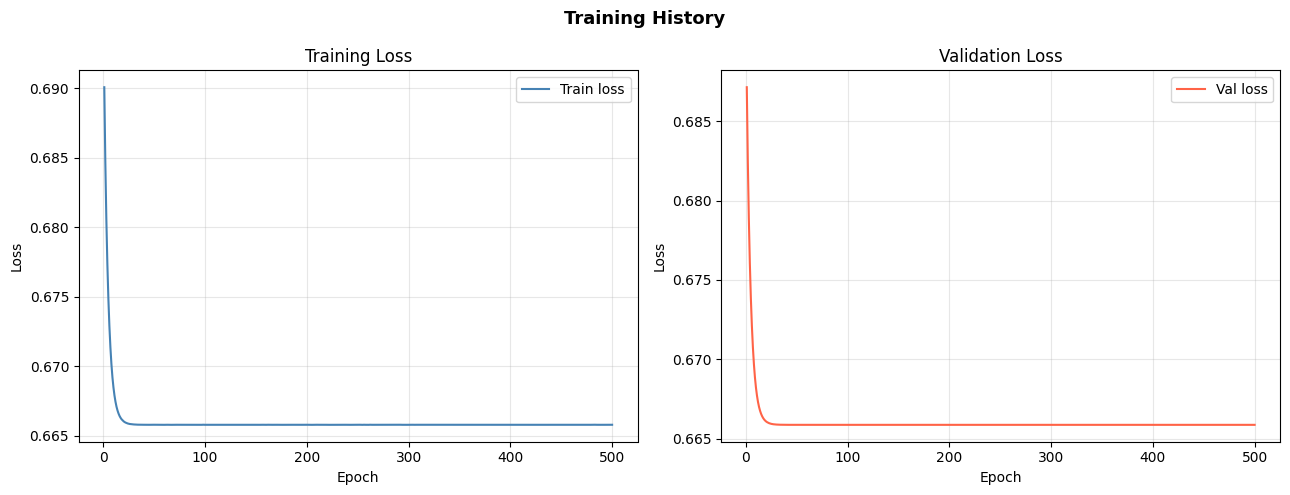

In [74]:
viz = Visualizer()
history = model_zero.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

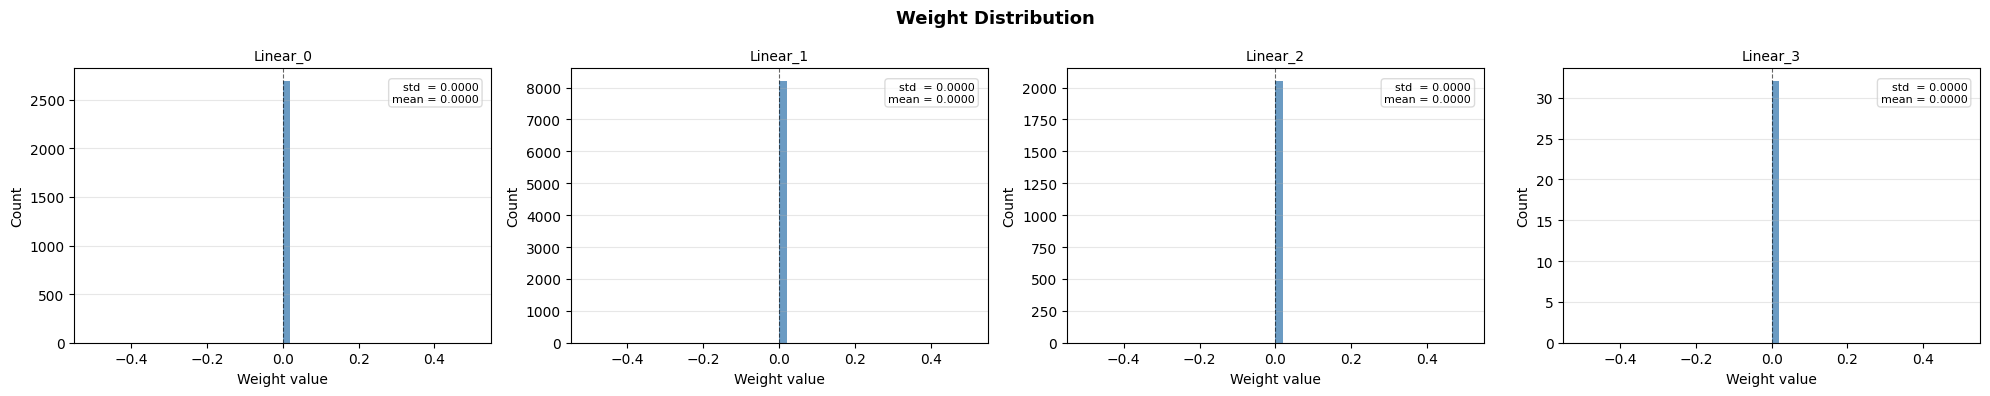

In [75]:
weights = model_zero.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

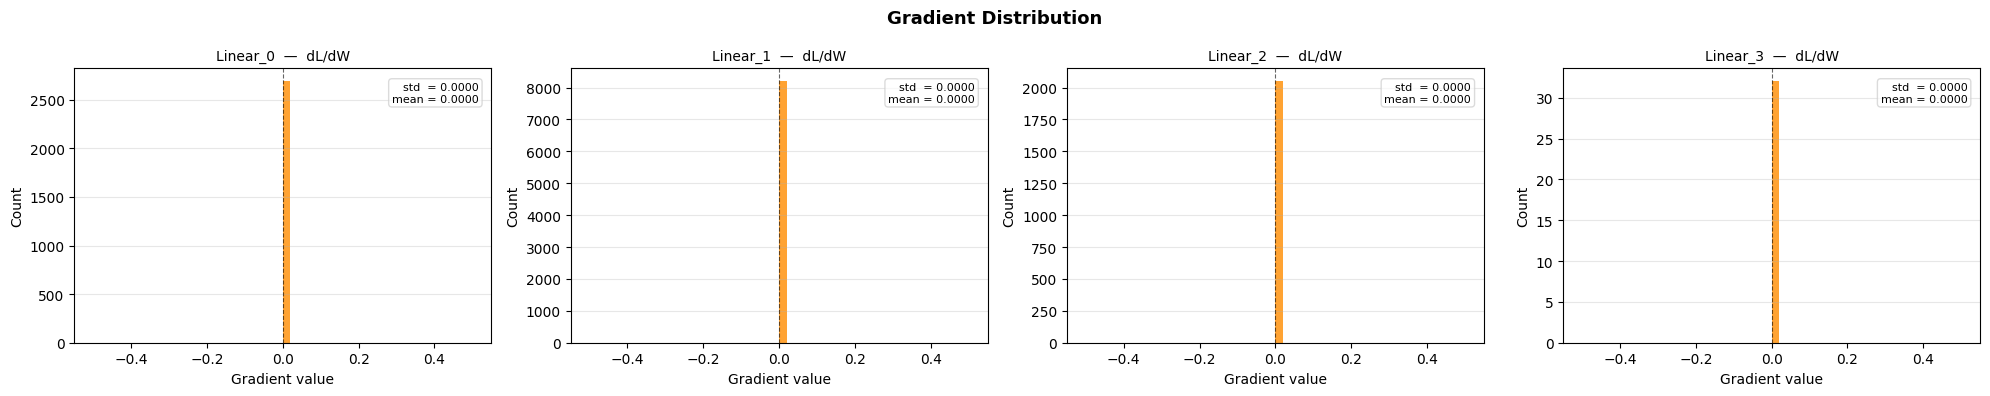

In [76]:
y_pred_viz = model_zero.forward(X_test)
model_zero.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_zero.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [77]:
y_pred  = model_zero.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6110


### Save Model

In [78]:
os.makedirs('../results', exist_ok=True)
model_zero.save('../results/zero_initializer.npz')

[FFNN] Model tersimpan di '../results/zero_initializer.npz' 


### Verifikasi Load Model

## Model 2: FFNN + Random Uniform Initialization

In [79]:
for epoch in range(1, EPOCHS + 1):
    metrics = model_uniform.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.7819  |  val_loss: 0.6111  |  val_acc: 0.7044
Epoch   2/500  |  train_loss: 0.6137  |  val_loss: 0.5611  |  val_acc: 0.7356
Epoch   3/500  |  train_loss: 0.5776  |  val_loss: 0.5402  |  val_acc: 0.7506
Epoch   4/500  |  train_loss: 0.5570  |  val_loss: 0.5291  |  val_acc: 0.7531
Epoch   5/500  |  train_loss: 0.5462  |  val_loss: 0.5215  |  val_acc: 0.7525
Epoch   6/500  |  train_loss: 0.5369  |  val_loss: 0.5160  |  val_acc: 0.7612
Epoch   7/500  |  train_loss: 0.5307  |  val_loss: 0.5136  |  val_acc: 0.7606
Epoch   8/500  |  train_loss: 0.5248  |  val_loss: 0.5107  |  val_acc: 0.7638
Epoch   9/500  |  train_loss: 0.5209  |  val_loss: 0.5070  |  val_acc: 0.7631
Epoch  10/500  |  train_loss: 0.5176  |  val_loss: 0.5083  |  val_acc: 0.7644
Epoch  11/500  |  train_loss: 0.5142  |  val_loss: 0.5026  |  val_acc: 0.7706
Epoch  12/500  |  train_loss: 0.5105  |  val_loss: 0.5033  |  val_acc: 0.7706
Epoch  13/500  |  train_loss: 0.5086  |  val_loss: 0.5007  |  va

### Visualisasi

### 1. Plot Traning History

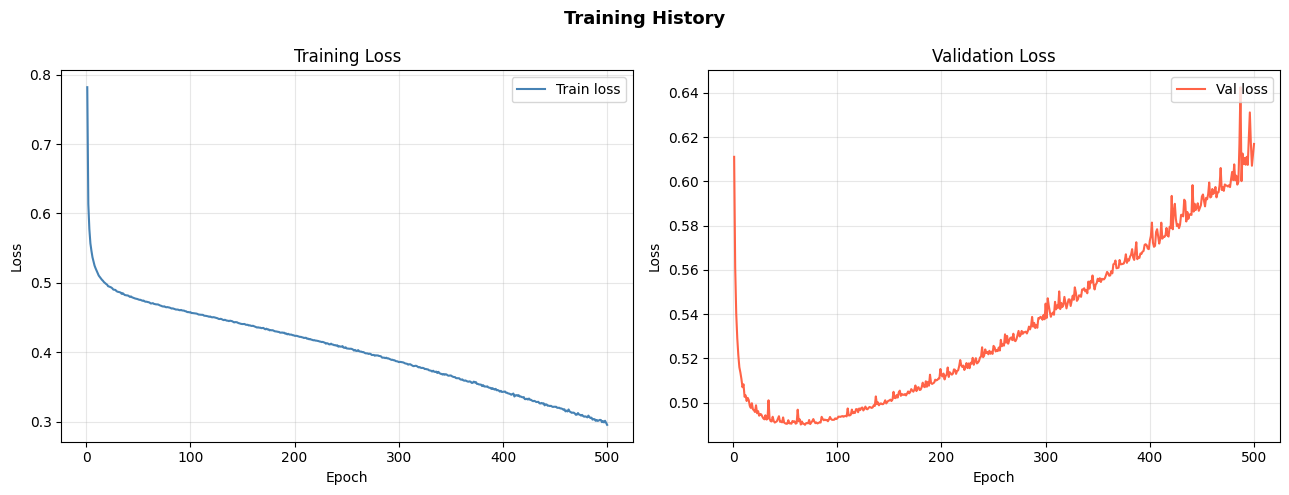

In [80]:
viz = Visualizer()
history = model_uniform.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

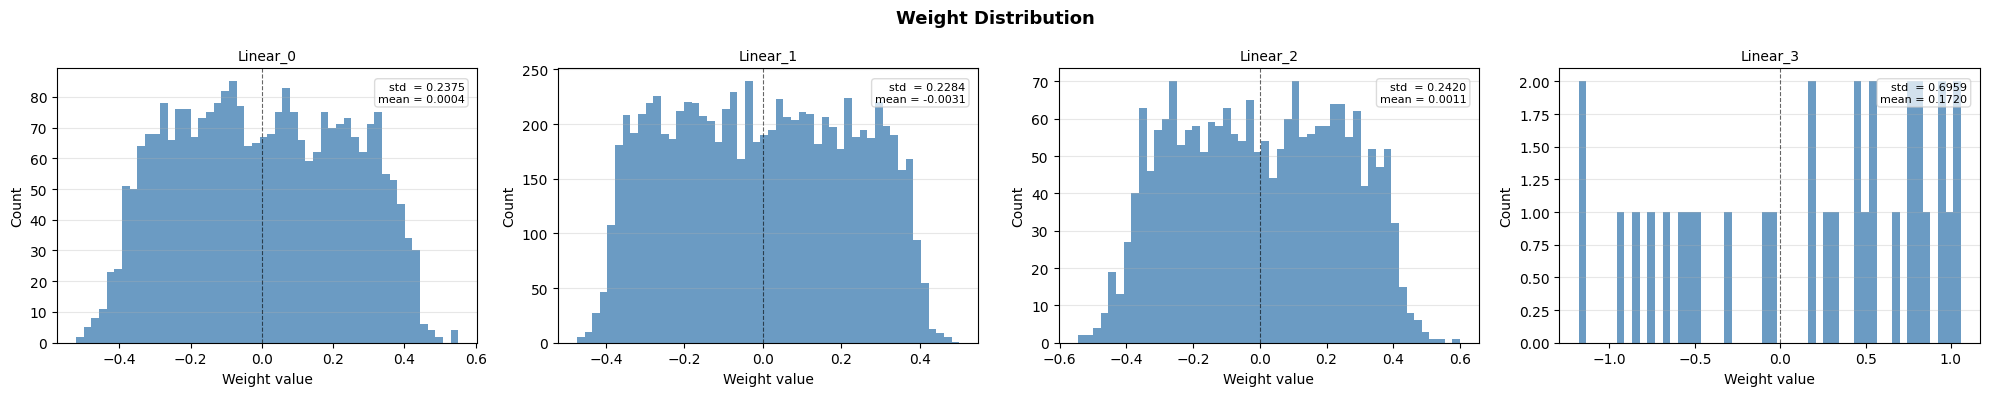

In [81]:
weights = model_uniform.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

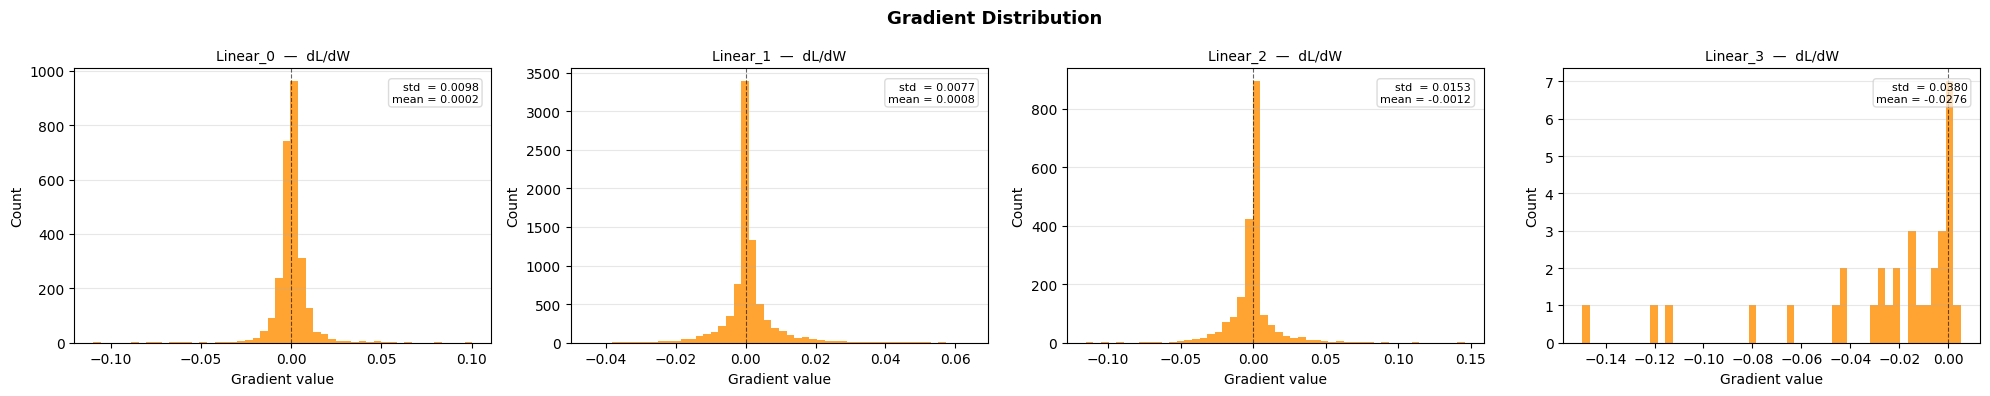

In [82]:
y_pred_viz = model_uniform.forward(X_test)
model_uniform.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_uniform.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [83]:
y_pred  = model_uniform.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7035


### Save Model

In [84]:
os.makedirs('../results', exist_ok=True)
model_uniform.save('../results/uniform_initializer.npz')

[FFNN] Model tersimpan di '../results/uniform_initializer.npz' 


### Verifikasi Load Model

## Model 3: FFNN + Normal Initialization

In [85]:
for epoch in range(1, EPOCHS + 1):
    metrics = model_normal.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 14.7366  |  val_loss: 11.5510  |  val_acc: 0.6600


c:\Users\ASUS\Documents\GitHub\FFNN-Scratch\src\model\activations.py:21: RuntimeWarning: overflow encountered in exp
  return 1/ (1 + np.exp(-x))


Epoch   2/500  |  train_loss: 11.5037  |  val_loss: 10.2254  |  val_acc: 0.6981
Epoch   3/500  |  train_loss: 9.8261  |  val_loss: 8.7273  |  val_acc: 0.7350
Epoch   4/500  |  train_loss: 9.2893  |  val_loss: 8.4542  |  val_acc: 0.7356
Epoch   5/500  |  train_loss: 9.5776  |  val_loss: 9.5019  |  val_acc: 0.7137
Epoch   6/500  |  train_loss: 8.9098  |  val_loss: 8.0212  |  val_acc: 0.7569
Epoch   7/500  |  train_loss: 8.8866  |  val_loss: 8.2975  |  val_acc: 0.7519
Epoch   8/500  |  train_loss: 8.5032  |  val_loss: 8.6812  |  val_acc: 0.7369
Epoch   9/500  |  train_loss: 8.5488  |  val_loss: 9.1929  |  val_acc: 0.7281
Epoch  10/500  |  train_loss: 8.6670  |  val_loss: 7.9128  |  val_acc: 0.7644
Epoch  11/500  |  train_loss: 8.3993  |  val_loss: 8.7010  |  val_acc: 0.7375
Epoch  12/500  |  train_loss: 8.5211  |  val_loss: 9.0280  |  val_acc: 0.7269
Epoch  13/500  |  train_loss: 8.3879  |  val_loss: 8.2910  |  val_acc: 0.7488
Epoch  14/500  |  train_loss: 8.3359  |  val_loss: 8.0791  |  

### Visualisasi

### 1. Plot Traning History

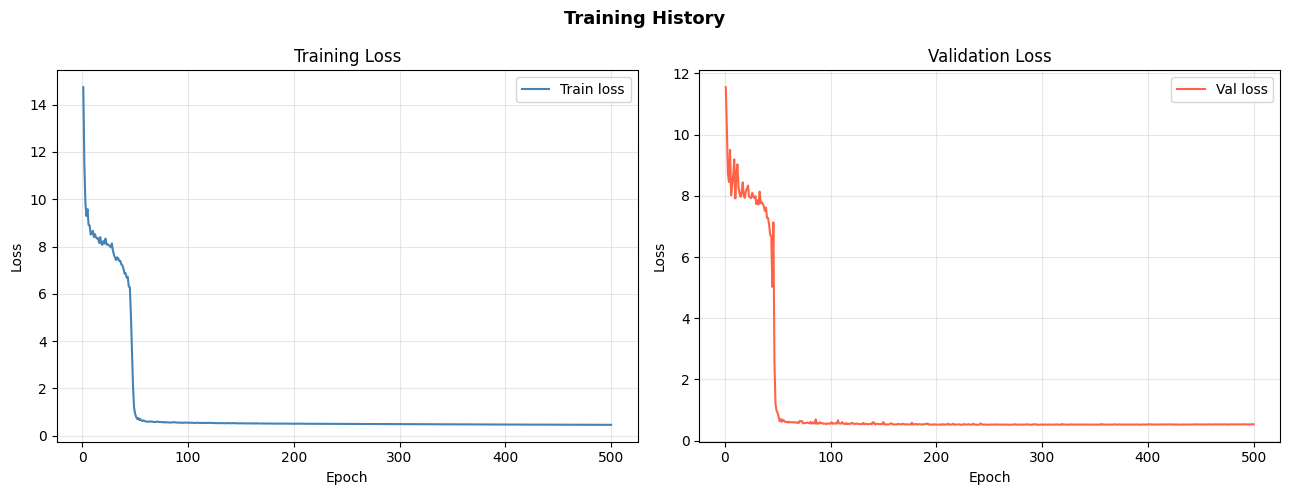

In [86]:
viz = Visualizer()
history = model_normal.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

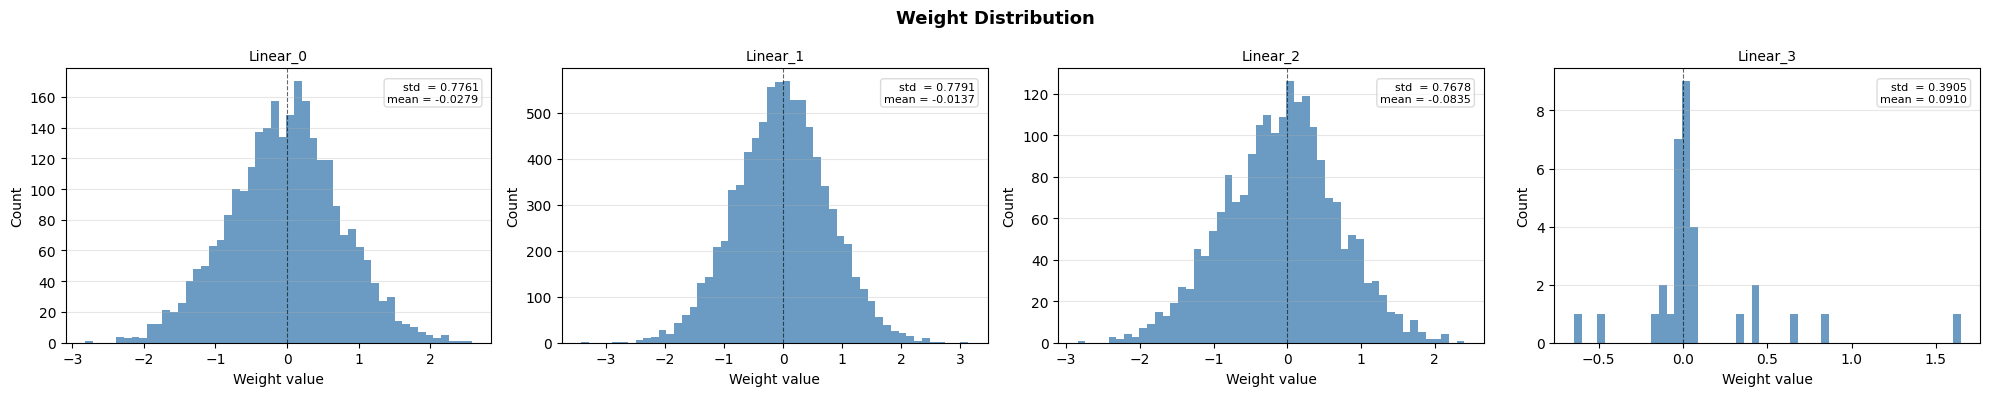

In [87]:
weights = model_normal.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

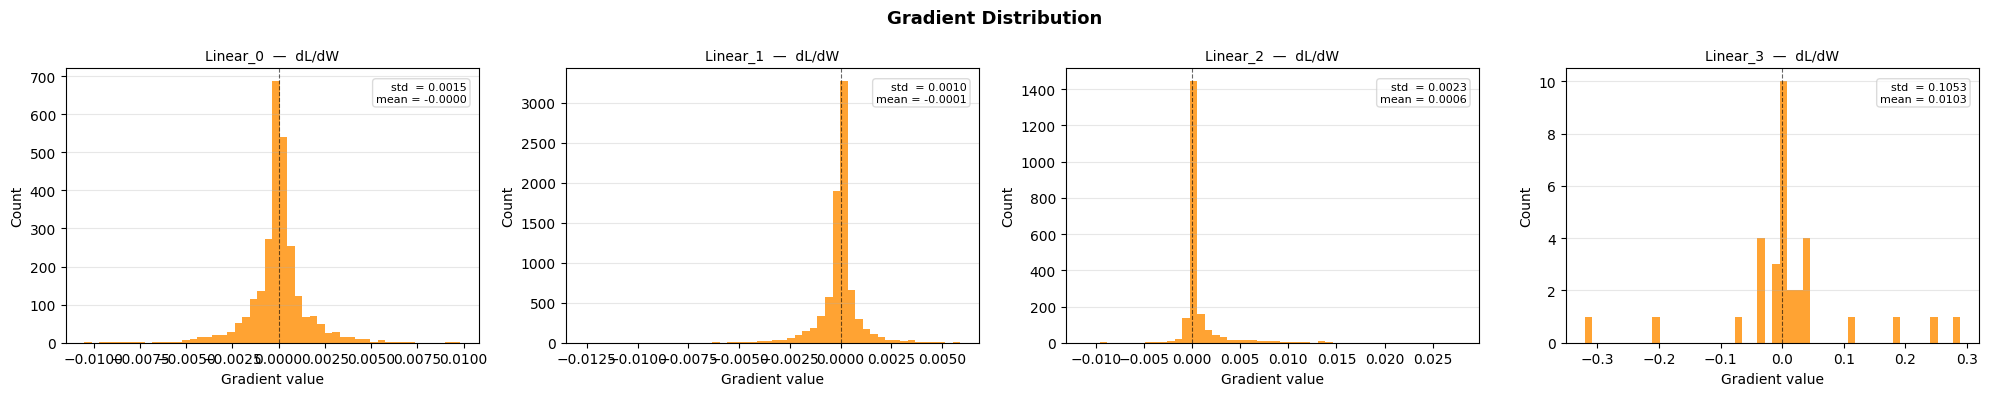

In [88]:
y_pred_viz = model_normal.forward(X_test)
model_normal.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_normal.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [89]:
y_pred  = model_normal.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7390


### Save Model

In [90]:
os.makedirs('../results', exist_ok=True)
model_normal.save('../results/normal_initializer.npz')

[FFNN] Model tersimpan di '../results/normal_initializer.npz' 


## Model 4: FFNN + Xavier Initialization

In [91]:
for epoch in range(1, EPOCHS + 1):
    metrics = model_xavier.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6379  |  val_loss: 0.6101  |  val_acc: 0.6469
Epoch   2/500  |  train_loss: 0.6055  |  val_loss: 0.5804  |  val_acc: 0.6706
Epoch   3/500  |  train_loss: 0.5814  |  val_loss: 0.5565  |  val_acc: 0.7175
Epoch   4/500  |  train_loss: 0.5616  |  val_loss: 0.5376  |  val_acc: 0.7369
Epoch   5/500  |  train_loss: 0.5455  |  val_loss: 0.5226  |  val_acc: 0.7519
Epoch   6/500  |  train_loss: 0.5329  |  val_loss: 0.5101  |  val_acc: 0.7569
Epoch   7/500  |  train_loss: 0.5234  |  val_loss: 0.5011  |  val_acc: 0.7631
Epoch   8/500  |  train_loss: 0.5163  |  val_loss: 0.4948  |  val_acc: 0.7656
Epoch   9/500  |  train_loss: 0.5110  |  val_loss: 0.4901  |  val_acc: 0.7662
Epoch  10/500  |  train_loss: 0.5075  |  val_loss: 0.4865  |  val_acc: 0.7662
Epoch  11/500  |  train_loss: 0.5047  |  val_loss: 0.4840  |  val_acc: 0.7650
Epoch  12/500  |  train_loss: 0.5025  |  val_loss: 0.4824  |  val_acc: 0.7631
Epoch  13/500  |  train_loss: 0.5008  |  val_loss: 0.4815  |  va

### Visualisasi

### 1. Plot Traning History

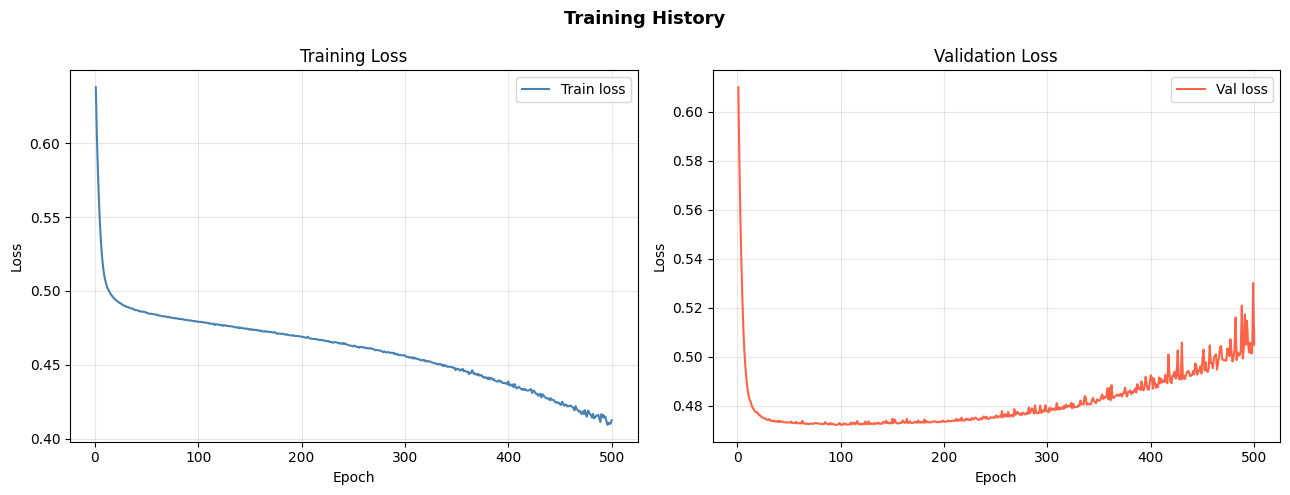

In [92]:
viz = Visualizer()
history = model_xavier.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

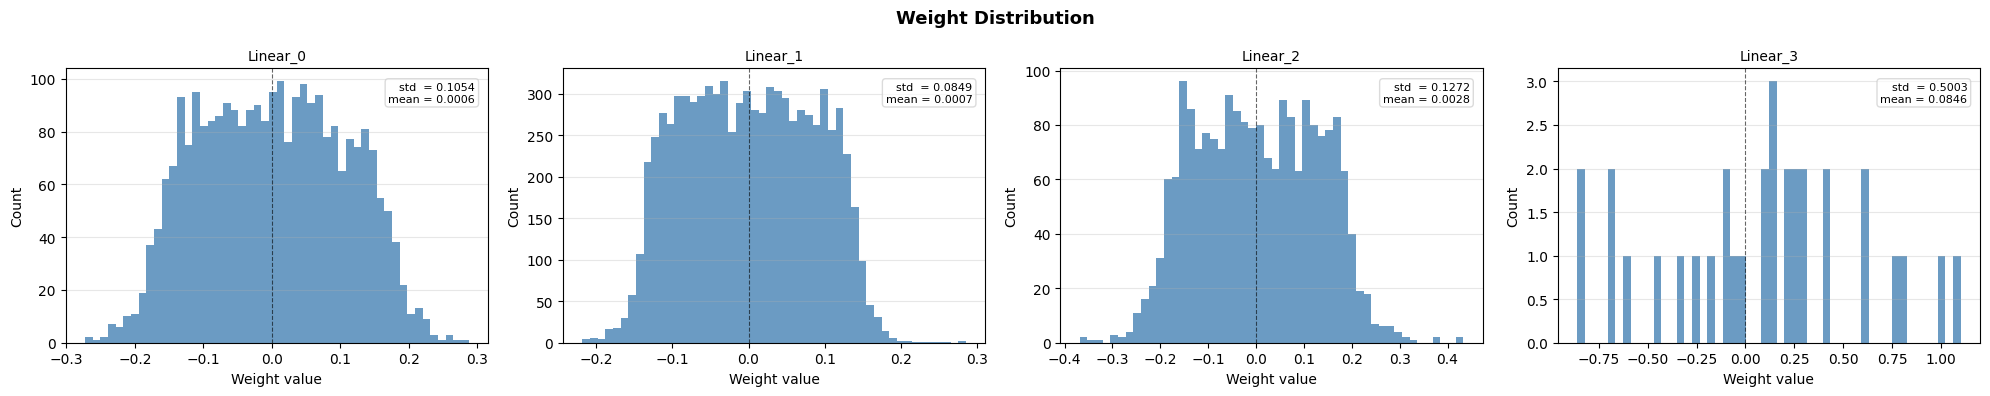

In [93]:
weights = model_xavier.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

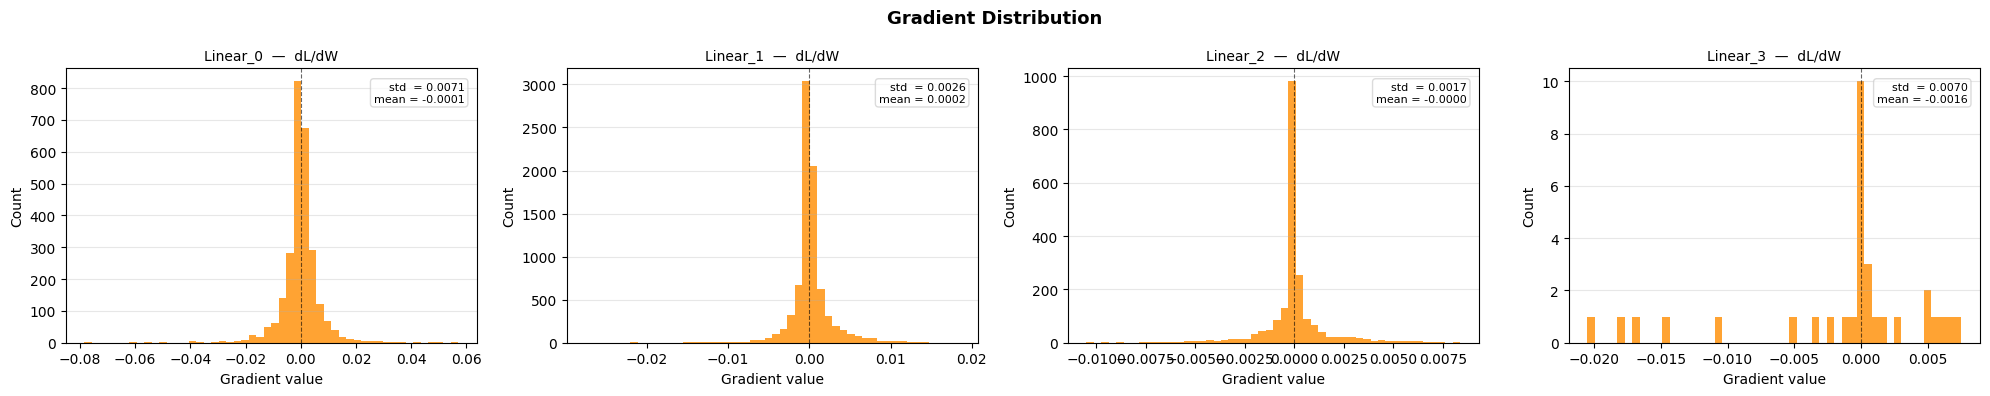

In [94]:
y_pred_viz = model_xavier.forward(X_test)
model_xavier.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_xavier.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [95]:
y_pred  = model_xavier.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7315


### Save Model

In [96]:
os.makedirs('../results', exist_ok=True)
model_xavier.save('../results/xavier_initializer.npz')

[FFNN] Model tersimpan di '../results/xavier_initializer.npz' 


## Model 5: FFNN + He Initialization

In [97]:
for epoch in range(1, EPOCHS + 1):
    metrics = model_he.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6828  |  val_loss: 0.6212  |  val_acc: 0.6512
Epoch   2/500  |  train_loss: 0.6071  |  val_loss: 0.5721  |  val_acc: 0.7131
Epoch   3/500  |  train_loss: 0.5687  |  val_loss: 0.5413  |  val_acc: 0.7419
Epoch   4/500  |  train_loss: 0.5446  |  val_loss: 0.5202  |  val_acc: 0.7462
Epoch   5/500  |  train_loss: 0.5298  |  val_loss: 0.5088  |  val_acc: 0.7544
Epoch   6/500  |  train_loss: 0.5211  |  val_loss: 0.5018  |  val_acc: 0.7538
Epoch   7/500  |  train_loss: 0.5149  |  val_loss: 0.4969  |  val_acc: 0.7575
Epoch   8/500  |  train_loss: 0.5109  |  val_loss: 0.4943  |  val_acc: 0.7600
Epoch   9/500  |  train_loss: 0.5078  |  val_loss: 0.4917  |  val_acc: 0.7612
Epoch  10/500  |  train_loss: 0.5055  |  val_loss: 0.4922  |  val_acc: 0.7588
Epoch  11/500  |  train_loss: 0.5040  |  val_loss: 0.4895  |  val_acc: 0.7625
Epoch  12/500  |  train_loss: 0.5022  |  val_loss: 0.4879  |  val_acc: 0.7631
Epoch  13/500  |  train_loss: 0.5011  |  val_loss: 0.4871  |  va

### 1. Plot Traning History

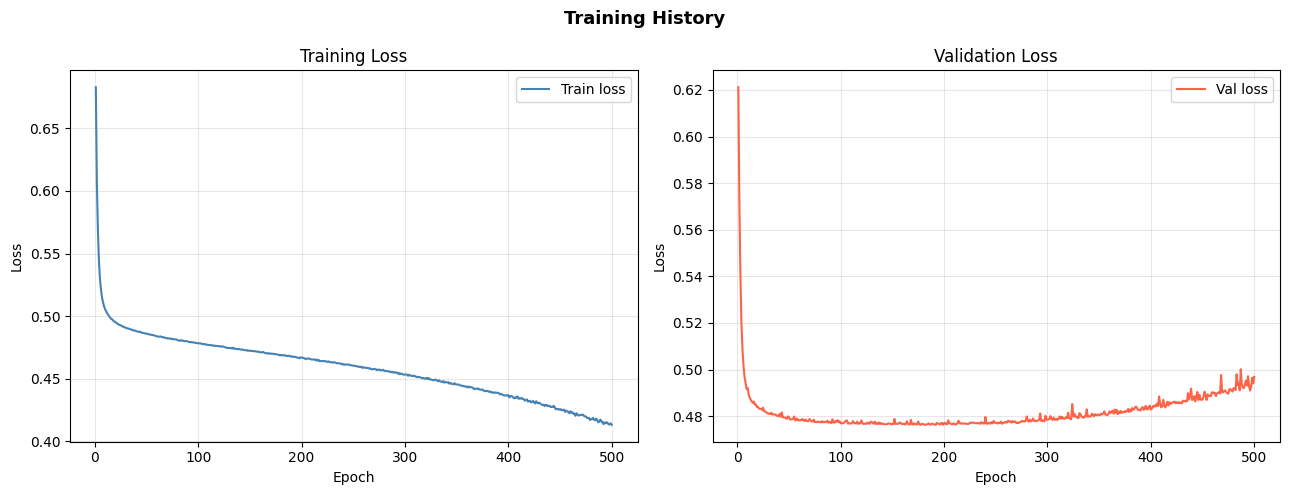

In [98]:
viz = Visualizer()
history = model_he.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

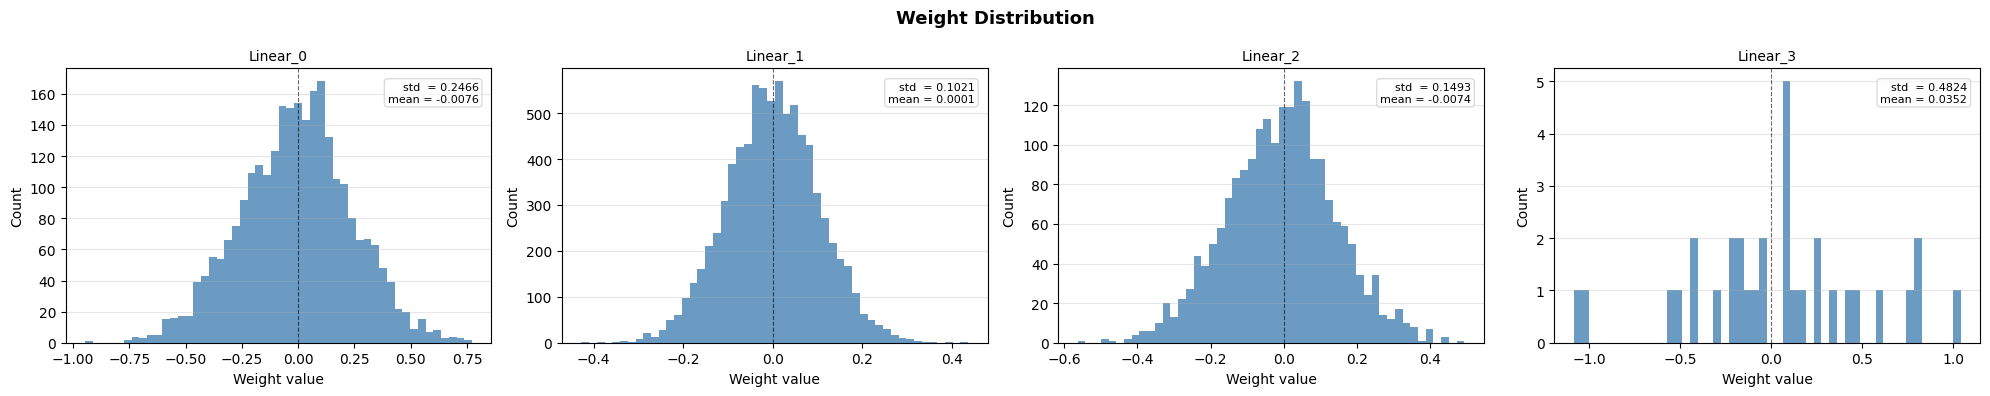

In [99]:
weights = model_he.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

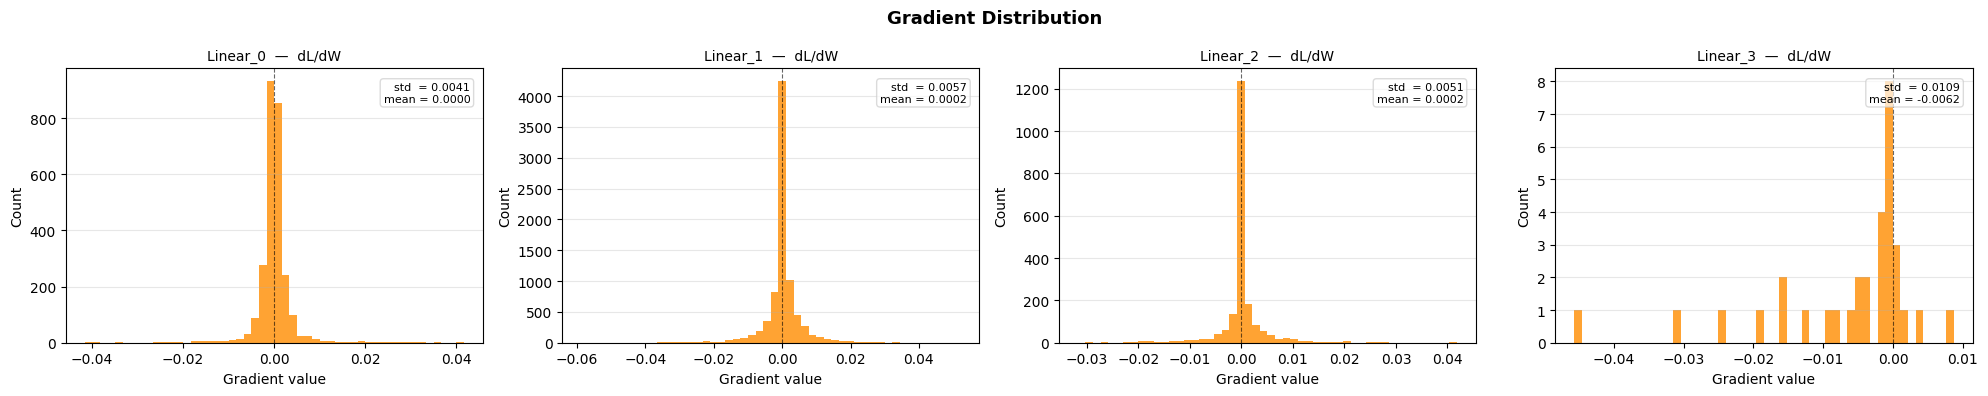

In [100]:
y_pred_viz = model_he.forward(X_test)
model_he.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_he.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [101]:
y_pred  = model_he.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7365


### Save Model

In [102]:
os.makedirs('../results', exist_ok=True)
model_he.save('../results/he_initializer.npz')

[FFNN] Model tersimpan di '../results/he_initializer.npz' 
